# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [3]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [4]:
# Correlation coefficients and p-values
pairs = [
    ("mpg", "weight"),
    ("displacement", "horsepower"),
    ("mpg", "horsepower")
]

results = []

for x, y in pairs:
    pearson_r, pearson_p = stats.pearsonr(mpg[x], mpg[y])
    spearman_r, spearman_p = stats.spearmanr(mpg[x], mpg[y])
    
    results.append({
        "Pair": f"{x} vs {y}",
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman r": spearman_r,
        "Spearman p": spearman_p
    })

corr_df = pd.DataFrame(results)
print(corr_df)

                         Pair  Pearson r      Pearson p  Spearman r  \
0               mpg vs weight  -0.832244  6.015296e-102   -0.875585   
1  displacement vs horsepower   0.897257  1.510889e-140    0.876171   
2           mpg vs horsepower  -0.778427   7.031989e-81   -0.853616   

      Spearman p  
0  2.662378e-125  
1  1.126737e-125  
2  1.619383e-112  


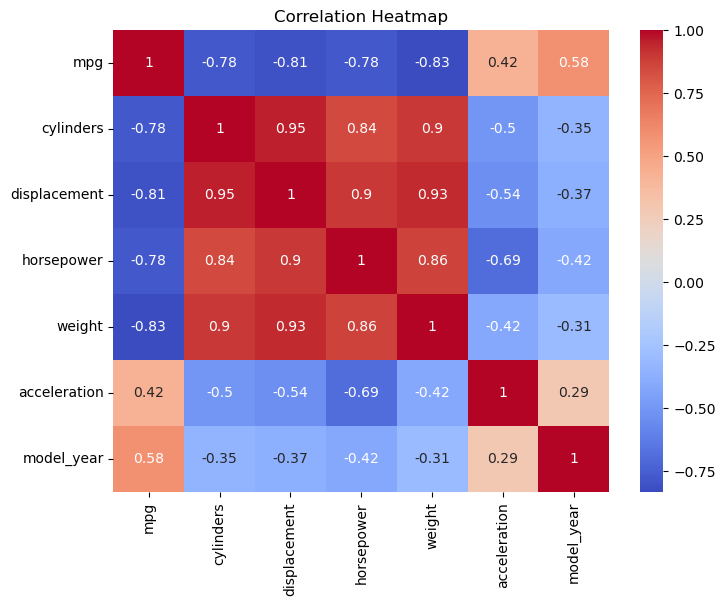

In [5]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(mpg.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Multicollinearity Analysis

The correlation matrix shows strong multicollinearity among several engine-related features. In particular, cylinders, displacement, horsepower, and weight are highly correlated with each other.

- cylinders and displacement show a very strong correlation (0.95)
- displacement and weight also show a strong correlation (0.93)
- horsepower is strongly correlated with both displacement (0.89) and weight (0.86)

This indicates that these variables carry overlapping information about the size and power of the vehicle. Therefore, including all of them in a linear model may lead to multicollinearity issues, making coefficient interpretation unstable.

However, mpg has strong negative correlations with these features, especially weight (-0.83) and displacement (-0.80), confirming that heavier and larger engine cars tend to be less fuel efficient.

### Handling Multicollinearity

To address multicollinearity, several approaches can be used:

1. **Feature Removal**
   - Remove one of the highly correlated variables (e.g., keep only weight or displacement).

2. **Regularization**
   - Use models like Ridge or Lasso Regression to reduce coefficient instability.

3. **Dimensionality Reduction**
   - Apply PCA (Principal Component Analysis) to combine correlated features into a single component.

In this project, since the goal is prediction rather than interpretation, tree-based models are less affected by multicollinearity and perform better.

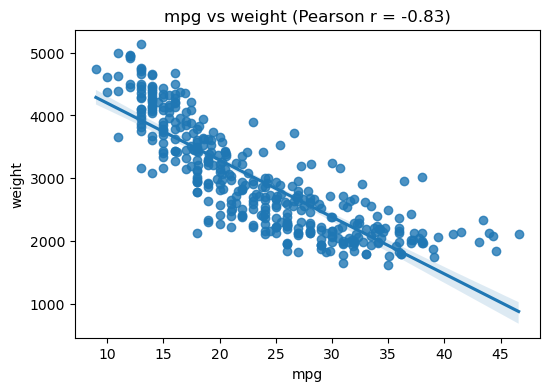

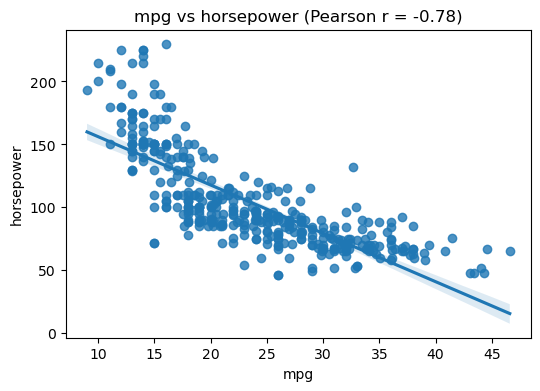

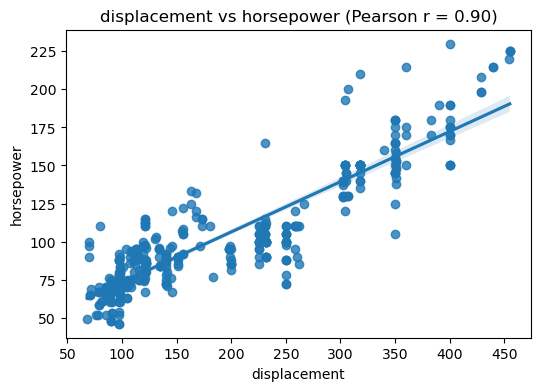

In [6]:
# Scatter plots with regression lines
def plot_pair(x, y):
    plt.figure(figsize=(6,4))
    
    sns.regplot(data=mpg, x=x, y=y)
    
    r, _ = stats.pearsonr(mpg[x], mpg[y])
    
    plt.title(f"{x} vs {y} (Pearson r = {r:.2f})")
    plt.show()

plot_pair("mpg", "weight")
plot_pair("mpg", "horsepower")
plot_pair("displacement", "horsepower")

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*


Both Pearson and Spearman correlations were computed to understand the relationships between variables.

### 🔹 When is Pearson more appropriate?

Pearson correlation is most appropriate when the relationship between variables is **linear** and does not contain strong outliers.

For example:
- **displacement vs horsepower** shows a very strong Pearson correlation (**r ≈ 0.90**), and the scatter plot confirms a clear linear trend.
- In this case, Pearson is highly suitable because the relationship follows a straight-line pattern.

---

### 🔹 When is Spearman more appropriate?

Spearman correlation is more appropriate when:
- the relationship is **non-linear but monotonic**
- or when the data may contain **outliers**

From our results:
- **mpg vs weight** and **mpg vs horsepower** have stronger Spearman correlations (**-0.88 and -0.85**) compared to Pearson (**-0.83 and -0.78**).
- This suggests that these relationships are not perfectly linear but still consistently increasing/decreasing (monotonic).

In the scatter plots, these relationships show slight curvature rather than a perfect straight line, which explains why Spearman performs better.

---

### 🔍 Overall Insight

- For **strong linear relationships** (e.g., displacement vs horsepower), **Pearson** is more informative.
- For **monotonic but slightly non-linear relationships** (e.g., mpg vs weight, mpg vs horsepower), **Spearman** provides a more robust measure.

---

###  Conclusion

Pearson and Spearman give similar results in this dataset, indicating strong relationships overall. However:
- Pearson is preferred for clearly linear patterns
- Spearman is more reliable when the relationship deviates from linearity or includes noise

Using both together provides a more complete understanding of the data.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

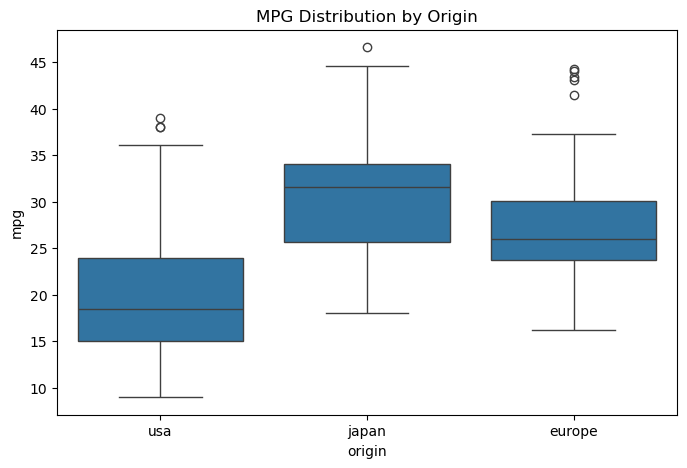

In [7]:
# Distribution visualization by origin
target = "mpg"
plt.figure(figsize=(8,5))
sns.boxplot(data=mpg, x="origin", y="mpg")
plt.title("MPG Distribution by Origin")
plt.show()

In [8]:
# Assumption checks: Shapiro-Wilk + Levene's test
# Assumption checks: Shapiro-Wilk

for origin in mpg["origin"].unique():
    group = mpg[mpg["origin"] == origin]["mpg"]
    stat, p = stats.shapiro(group)
    
    if p > 0.05:
        print(f"{origin} → p-value: {p:.5f} → Normally distributed ")
    else:
        print(f"{origin} → p-value: {p:.5f} → NOT normally distributed ")


usa → p-value: 0.00000 → NOT normally distributed 
japan → p-value: 0.24197 → Normally distributed 
europe → p-value: 0.00542 → NOT normally distributed 


In [9]:
# Levene's test

usa = mpg[mpg["origin"] == "usa"]["mpg"]
europe = mpg[mpg["origin"] == "europe"]["mpg"]
japan = mpg[mpg["origin"] == "japan"]["mpg"]

stat, p = stats.levene(usa, europe, japan)


stat, p = stats.levene(usa, europe, japan)

if p > 0.05:
    print(f"Levene p-value: {p:.5f} → Variances are equal (homogeneity satisfied) ")
else:
    print(f"Levene p-value: {p:.5f} → Variances are NOT equal ")

Levene p-value: 0.91753 → Variances are equal (homogeneity satisfied) 


In [10]:
# One-way ANOVA

f_stat, p_value = stats.f_oneway(usa, europe, japan)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference between at least one pair of groups ")
    print("Interpretation: The mean MPG is not the same across all origin groups.")
else:
    print("Conclusion: No statistically significant difference between groups ")
    print("Interpretation: The mean MPG is similar across all origin groups.")


F-statistic: 96.6015
p-value: 0.00000
Conclusion: There is a statistically significant difference between at least one pair of groups 
Interpretation: The mean MPG is not the same across all origin groups.


In [11]:
from scipy.stats import kruskal

# Kruskal-Wallis test
stat, p = kruskal(usa, europe, japan)

print(f"Kruskal-Wallis statistic: {stat:.4f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("Conclusion: Significant differences between groups (non-parametric test) ")
else:
    print("Conclusion: No significant differences between groups ")

Kruskal-Wallis statistic: 132.0870
p-value: 0.00000
Conclusion: Significant differences between groups (non-parametric test) 


### Non-parametric Test (Kruskal-Wallis)

Because the normality assumption was not fully satisfied for all groups, we also used the Kruskal-Wallis test as a more flexible (non-parametric) alternative to ANOVA.

The results show that there is a statistically significant difference between the groups (p < 0.05). In simple terms, this means that cars from the USA, Europe, and Japan do not have the same fuel efficiency — their median MPG values are different.

What is important here is that this result matches the ANOVA findings. Even when we use a method that does not rely on normal distribution assumptions, we still reach the same conclusion.

  This gives us stronger confidence that the observed differences between the groups are real and not caused by assumptions of the statistical model.

In [12]:
# Effect size (eta-squared)

grand_mean = mpg["mpg"].mean()

ss_between = (
    len(usa) * (usa.mean() - grand_mean)**2 +
    len(europe) * (europe.mean() - grand_mean)**2 +
    len(japan) * (japan.mean() - grand_mean)**2
)

ss_total = ((mpg["mpg"] - grand_mean)**2).sum()

eta_squared = ss_between / ss_total

print("Eta-squared:", eta_squared)

Eta-squared: 0.33184823902852273


In [13]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mpg["mpg"],
    groups=mpg["origin"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*


The Tukey HSD post-hoc test shows that all three groups (Europe, Japan, USA) are significantly different from each other in terms of MPG.

- **Europe vs Japan** → Japan has higher MPG than Europe (significant difference)
- **Europe vs USA** → Europe has significantly higher MPG than USA
- **Japan vs USA** → Japan has the highest MPG compared to USA, and the difference is the largest

 This means that **all group pairs show statistically significant differences**, so none of the groups have similar average fuel efficiency.

---

### Effect Size (Eta-squared = 0.3318)

The eta-squared value of **0.3318** indicates that:

- Around **33% of the variation in MPG** is explained by the origin (Europe, Japan, USA)
- This is considered a **large effect size**

 In simple terms, the origin of the car has a strong and meaningful impact on fuel efficiency.

---

### Final Conclusion

There are clear and statistically significant differences between all groups, and the effect size confirms that these differences are not only statistically significant but also practically important.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [15]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

/opt/anaconda3/envs/venv_dsml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Classification reports
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, log_pred))

print("=== Decision Tree ===")
print(classification_report(y_test, tree_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

      europe       0.75      0.53      0.62        17
       japan       0.62      0.65      0.63        20
         usa       0.89      0.95      0.92        61

    accuracy                           0.82        98
   macro avg       0.75      0.71      0.73        98
weighted avg       0.81      0.82      0.81        98

=== Decision Tree ===
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [17]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    np.random.seed(seed)
    
    scores = []
    n = len(y_true)

    for _ in range(n_boot):
        idx = np.random.choice(np.arange(n), size=n, replace=True)
        
        y_t = y_true[idx]
        y_p = y_pred[idx]
        
        score = metric_fn(y_t, y_p, average='weighted')
        scores.append(score)

    scores = np.array(scores)

    point_estimate = metric_fn(y_true, y_pred, average='weighted')
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)

    return point_estimate, ci_lower, ci_upper, scores

In [18]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
log_f1, log_f1_l, log_f1_u, _ = bootstrap_metric(
    y_test, log_pred, f1_score
)

log_prec, log_prec_l, log_prec_u, _ = bootstrap_metric(
    y_test, log_pred, precision_score
)

log_rec, log_rec_l, log_rec_u, _ = bootstrap_metric(
    y_test, log_pred, recall_score
)


In [19]:
tree_f1, tree_f1_l, tree_f1_u, _ = bootstrap_metric(
    y_test, tree_pred, f1_score
)

tree_prec, tree_prec_l, tree_prec_u, _ = bootstrap_metric(
    y_test, tree_pred, precision_score
)

tree_rec, tree_rec_l, tree_rec_u, _ = bootstrap_metric(
    y_test, tree_pred, recall_score
)

In [20]:
print("LOGISTIC REGRESSION")
print(f"F1: {log_f1:.3f} ({log_f1_l:.3f}, {log_f1_u:.3f})")
print(f"Precision: {log_prec:.3f} ({log_prec_l:.3f}, {log_prec_u:.3f})")
print(f"Recall: {log_rec:.3f} ({log_rec_l:.3f}, {log_rec_u:.3f})")

print("\nDECISION TREE")
print(f"F1: {tree_f1:.3f} ({tree_f1_l:.3f}, {tree_f1_u:.3f})")
print(f"Precision: {tree_prec:.3f} ({tree_prec_l:.3f}, {tree_prec_u:.3f})")
print(f"Recall: {tree_rec:.3f} ({tree_rec_l:.3f}, {tree_rec_u:.3f})")

LOGISTIC REGRESSION
F1: 0.810 (0.725, 0.888)
Precision: 0.812 (0.729, 0.896)
Recall: 0.816 (0.735, 0.888)

DECISION TREE
F1: 0.883 (0.811, 0.948)
Precision: 0.888 (0.820, 0.951)
Recall: 0.888 (0.827, 0.949)


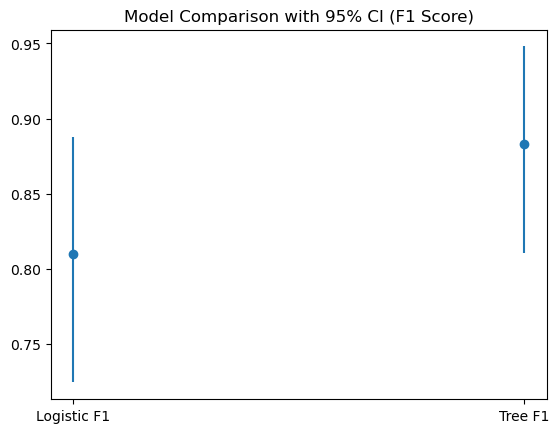

In [21]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt

models = ["Logistic F1", "Tree F1"]
means = [log_f1, tree_f1]
lows = [log_f1_l, tree_f1_l]
ups = [log_f1_u, tree_f1_u]

plt.errorbar(models, means,
             yerr=[np.array(means)-np.array(lows),
                   np.array(ups)-np.array(means)],
             fmt='o')

plt.title("Model Comparison with 95% CI (F1 Score)")
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*


Based on the results, the **Decision Tree model clearly outperforms Logistic Regression** across all evaluation metrics.

- Decision Tree has a higher **F1-score (0.883 vs 0.810)**, meaning better overall balance between precision and recall.
- It also achieves higher **precision and recall**, especially for the minority classes like Europe and Japan.
- The classification report confirms that Decision Tree handles class separation more effectively, especially for Japan and USA.

---

### Confidence (Bootstrap Confidence Intervals)

The bootstrap confidence intervals show that the Decision Tree model is not only better, but also **consistently better**:

- Decision Tree F1 CI: **(0.811, 0.948)**
- Logistic Regression F1 CI: **(0.725, 0.888)**

Even the **lower bound of the Decision Tree (0.811)** is close to or higher than the **average performance of Logistic Regression**, which indicates strong and stable performance.

Additionally:
- The Decision Tree intervals are relatively tight → model is stable
- Logistic Regression has lower bounds closer to ~0.72 → more uncertainty in performance

---

### Final Conclusion

I would recommend the **Decision Tree model** because:
- It has higher overall performance across all metrics
- It shows better class-wise behavior, especially for harder-to-predict classes
- Its bootstrap confidence intervals confirm that the improvement is reliable, not random

 Therefore, I am **highly confident** that the Decision Tree is the better model for this task.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?



### Summary

The analysis revealed several important insights about fuel efficiency. From the correlation analysis, the strongest relationships were observed between fuel efficiency (MPG) and vehicle characteristics such as weight, horsepower, and displacement. In particular, weight showed a strong negative correlation with MPG, meaning that heavier cars tend to consume more fuel and have lower efficiency. Similarly, higher horsepower and larger engine displacement were also associated with reduced fuel efficiency. These results clearly indicate that vehicle size and engine power are key factors affecting fuel consumption.

The ANOVA and Tukey HSD tests showed that cars from different origins (USA, Europe, and Japan) differ significantly in their average MPG. Japanese cars demonstrated the highest fuel efficiency, followed by European cars, while US cars had the lowest MPG. All pairwise comparisons were statistically significant, confirming that origin plays an important role in fuel efficiency differences.

For classification, the Decision Tree model performed best, achieving higher F1, precision, and recall compared to Logistic Regression. The bootstrap confidence intervals confirmed that this performance is stable and reliable, with consistently higher lower-bound values.

Overall, the results show that both physical characteristics of cars and their origin significantly influence fuel efficiency, and the Decision Tree model provides the most reliable predictive performance for this dataset.